<center> <h1> Netflix Content Segmentation Project using KMeans </h1> </center>

In [94]:
#Import required libraries:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from scipy.stats import ttest_ind

In [95]:

df = pd.read_csv("dataset/NetFlix.csv/NetFlix.csv")
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df = df.drop_duplicates().copy()


df.replace(["nan", "None", ""], np.nan, inplace=True)

text_cols = ["director", "cast", "country", "rating", "genres", "description"]
for col in text_cols:
    df[col] = df[col].fillna("Unknown").astype(str).str.strip()

df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce", dayfirst=True)
df["date_added"] = df["date_added"].fillna(df["date_added"].dropna().median())


df["release_year"] = pd.to_numeric(df["release_year"], errors="coerce")
df["release_year"] = df["release_year"].fillna(df["release_year"].median())

df["duration"] = (
    df["duration"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
)
df["duration"] = pd.to_numeric(df["duration"], errors="coerce")
df["duration"] = df["duration"].fillna(df["duration"].median())



df["duration"] = df.apply(
    lambda row: row["duration"] * 60 if row["type"] == "Movie"
    else row["duration"] * 360,
    axis=1
)

In [96]:
df["added_year"] = df["date_added"].dt.year
df["added_month"] = df["date_added"].dt.month

df["cast_count"] = df["cast"].apply(lambda x: 0 if x == "Unknown" else len([i for i in x.split(",") if i.strip()]))
df["country_count"] = df["country"].apply(
    lambda x: round(
        0 if x == "Unknown" else len([i for i in str(x).split(",") if i.strip()])
    )
)
df["country_count"] = df["country_count"].astype(int)
df["genre_count"] = df["genres"].apply(lambda x: 0 if x == "Unknown" else len([i for i in x.split(",") if i.strip()]))
df["description_length"] = df["description"].apply(lambda x: len(str(x).strip()))

(7787, 18)
show_id               0
type                  0
title                 0
director              0
cast                  0
country               0
date_added            0
release_year          0
rating                0
duration              0
genres                0
description           0
added_year            0
added_month           0
cast_count            0
country_count         0
genre_count           0
description_length    0
dtype: int64

Content Type Distribution:
type
Movie      5377
TV Show    2410
Name: count, dtype: int64

Rating Distribution:
rating
TV-MA    2863
TV-14    1931
TV-PG     806
R         665
PG-13     386
TV-Y      280
TV-Y7     271
PG        247
TV-G      194
NR         84
Name: count, dtype: int64


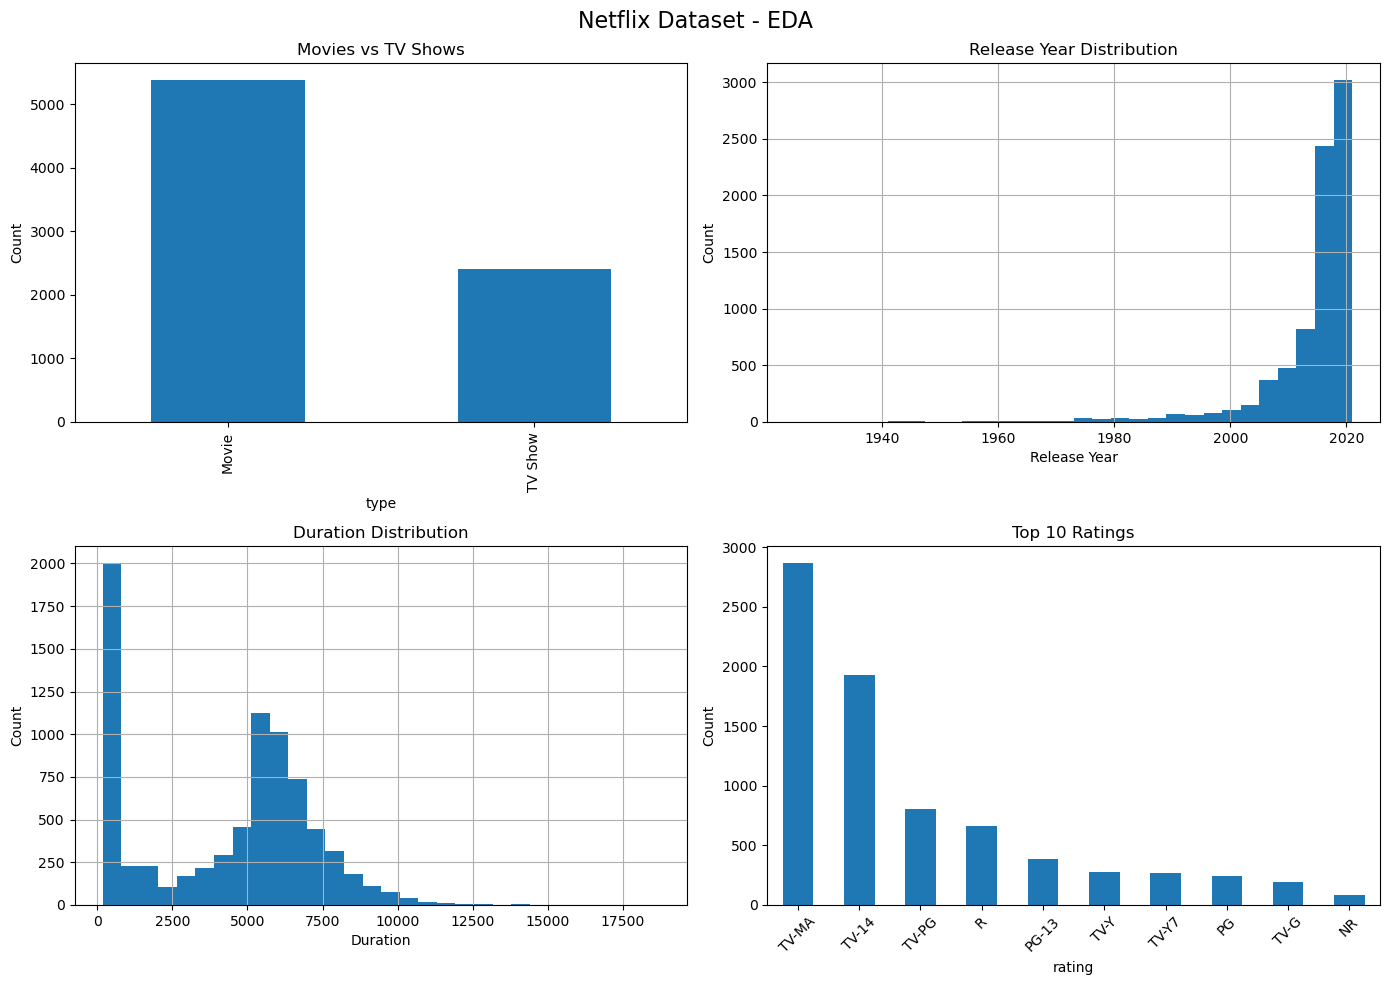

In [97]:
import matplotlib.pyplot as plt

print(df.shape)
print(df.isnull().sum())

print("\nContent Type Distribution:")
print(df["type"].value_counts())

print("\nRating Distribution:")
print(df["rating"].value_counts().head(10))

plt.figure(figsize=(14, 10))   




plt.subplot(2, 2, 1)
df["type"].value_counts().plot(kind="bar")
plt.title("Movies vs TV Shows")
plt.ylabel("Count")

plt.subplot(2, 2, 2)
df["release_year"].hist(bins=30)
plt.title("Release Year Distribution")
plt.xlabel("Release Year")
plt.ylabel("Count")

plt.subplot(2, 2, 3)
df["duration"].hist(bins=30)
plt.title("Duration Distribution")
plt.xlabel("Duration")
plt.ylabel("Count")

plt.subplot(2, 2, 4)
df["rating"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Ratings")
plt.ylabel("Count")
plt.xticks(rotation=45)    

plt.suptitle("Netflix Dataset - EDA", fontsize=16)
plt.tight_layout()             
plt.show()

### Q1] Help Netflix decide whether a content is rich or a simple content?

Accuracy: 0.9088575096277278
              precision    recall  f1-score   support

Content-Rich       0.83      1.00      0.91       709
      Simple       1.00      0.84      0.91       849

    accuracy                           0.91      1558
   macro avg       0.92      0.92      0.91      1558
weighted avg       0.92      0.91      0.91      1558



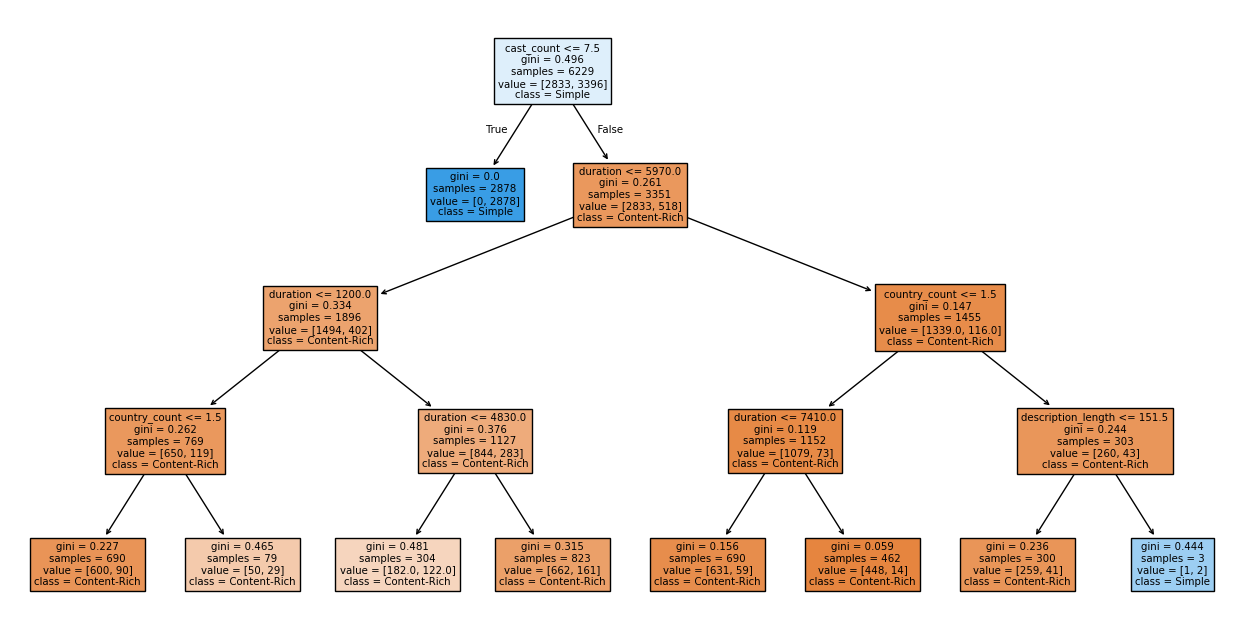

In [98]:
df["content_type"] = np.where(
    (df["genre_count"] >= df["genre_count"].median()) &
    (df["cast_count"] >= df["cast_count"].median()),
    "Content-Rich",
    "Simple"
)

X = df[["duration", "cast_count", "country_count", "description_length"]]
y = df["content_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

plt.figure(figsize=(16, 8))
plot_tree(model, feature_names=X.columns, class_names=model.classes_, filled=True)
plt.show()

### Q2] Netflix wants to check whether the average duration of Movies is different from the average duration of TV Shows in its catalog. Use an appropriate statistical test to determine if the difference is significant.

In [99]:

avg_movie_duration = df[df["type"]=="Movie"]["duration"]
avg_tv_show_duration = df[df["type"]=="TV Show"]["duration"]


from scipy import stats


t_stat, p_val = stats.ttest_ind(avg_movie_duration, avg_tv_show_duration,equal_var=False)

alpha = 0.05
if p_val < alpha:
    print("Reject null hypothesis: Significant difference found.")
else:
    print("Fail to reject null hypothesis: No significant difference.")

Reject null hypothesis: Significant difference found.


### Q3] Netflix claims that the average duration of newly released content (after 2020) is 100 minutes. Using the available data, test whether the average duration is actually less than 100 minutes at a 5% significance level.

In [100]:
from statsmodels.stats.weightstats import ztest

new_content = df[
    (df["release_year"] > 2020)
]["duration"].dropna()

population_mean = 100
alpha = 0.05

z_stat, p_value = ztest(new_content, value=population_mean)

p_value = p_value / 2 if z_stat < 0 else 1 - p_value / 2

print(f"Z-Score = {z_stat:.4f}, P-Value = {p_value:.4f}")

if p_value < alpha:
    print("Reject H0: Average duration is significantly less than 100 minutes.")
else:
    print("Fail to reject H0: No evidence that average duration is less than 100.")

Z-Score = 5.1466, P-Value = 1.0000
Fail to reject H0: No evidence that average duration is less than 100.


### Q4] Netflix wants to segment its content library to improve recommendation systems and optimize content investment strategy.

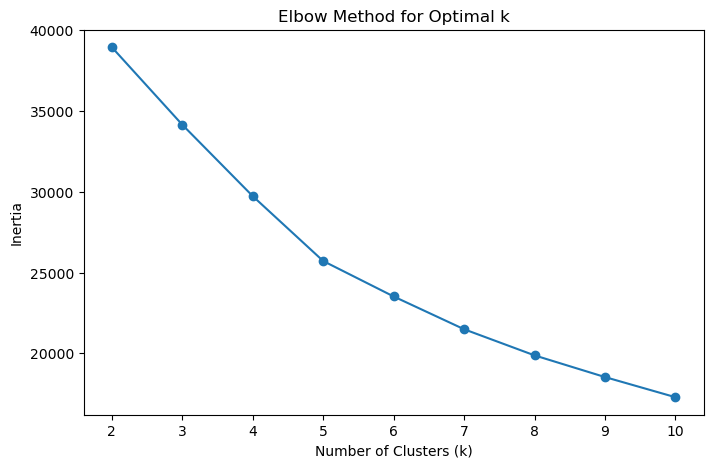

Cluster Profile:

         duration  genre_count  cast_count  country_count  description_length  \
cluster                                                                         
0         6630.20         2.33        8.53           1.12              150.06   
1         3296.63         1.28        3.36           0.97              143.19   
2         5279.22         2.15        8.11           3.63              143.15   
3          655.58         2.69        8.78           0.96              142.32   
4         6519.31         2.54        8.63           1.11              142.45   

         release_year  
cluster                
0             1986.18  
1             2016.46  
2             2013.91  
3             2016.62  
4             2014.77  

Cluster Sizes:

   cluster                          cluster_label  count
0        0         Classic Long-Form Rich Content    451
1        1  Moderate-Length Simple Recent Content   2137
2        2          Global Long-Form Rich Content    383
3

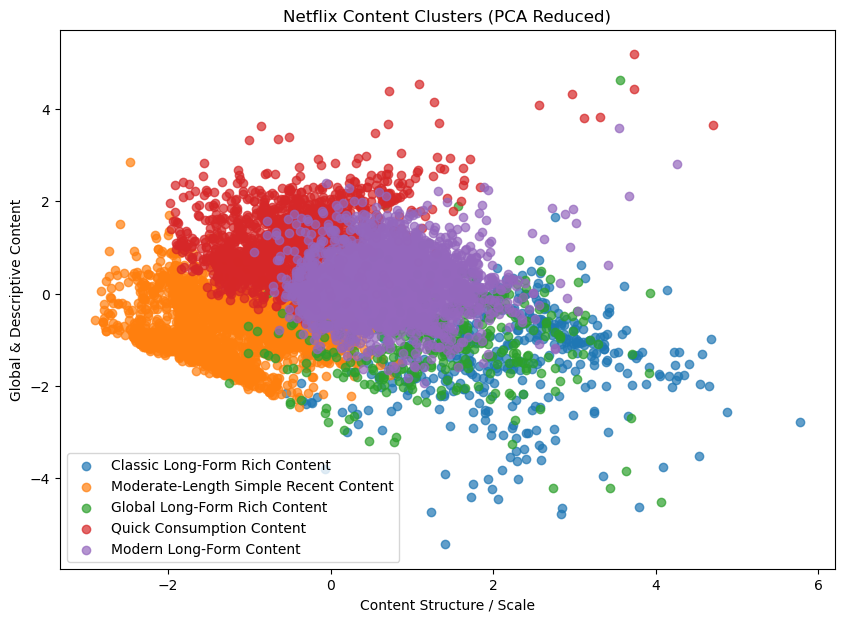

In [101]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


feature_cols = [
    "duration",
    "genre_count",
    "cast_count",
    "country_count",
    "description_length",
    "release_year"
]

X = df[feature_cols].copy()


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


inertias = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()


optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters







cluster_profile = df.groupby("cluster")[feature_cols].mean().round(2)
print("Cluster Profile:\n")
print(cluster_profile)





cluster_names = {
    0: "Classic Long-Form Rich Content",
    1: "Moderate-Length Simple Recent Content",
    2: "Global Long-Form Rich Content",
    3: "Quick Consumption Content",
    4: "Modern Long-Form Content"
}

df["cluster_label"] = df["cluster"].map(cluster_names)


cluster_sizes = (
    df.groupby(["cluster", "cluster_label"])
      .size()
      .reset_index(name="count")
      .sort_values("cluster")
)

print("\nCluster Sizes:\n")
print(cluster_sizes)



plt.figure(figsize=(10, 7))

for i in range(optimal_k):
    plt.scatter(
        X_pca[clusters == i, 0],
        X_pca[clusters == i, 1],
        label=cluster_names[i],
        alpha=0.7
    )

plt.xlabel("Content Structure / Scale")
plt.ylabel("Global & Descriptive Content")
plt.title("Netflix Content Clusters (PCA Reduced)")
plt.legend()
plt.show()

In [102]:
pca_df = pd.DataFrame(
    pca.components_,
    columns=feature_cols,
    index=["PC1", "PC2"]
)

print(pca_df)

     duration  genre_count  cast_count  country_count  description_length  \
PC1  0.551497     0.395531    0.474079       0.320384            0.096749   
PC2 -0.320656     0.615081    0.439104      -0.262664           -0.373546   

     release_year  
PC1     -0.450167  
PC2      0.342804  


In [103]:
from sklearn.metrics import silhouette_score

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    print(f"k={k}, silhouette={silhouette_score(X_scaled, labels):.3f}")

k=2, silhouette=0.190
k=3, silhouette=0.205
k=4, silhouette=0.229
k=5, silhouette=0.253
k=6, silhouette=0.255
k=7, silhouette=0.263
k=8, silhouette=0.260
k=9, silhouette=0.231


#### we got best silhoette score at 5-7 (mostly the same) but still we will go with no. of clusters as 4 because at k=5 and 6 most of the clusters were overlapping and the data doesnt naturally support this.

## Project by:
- **Name** : Om Satyawan Pathak
- **Email** : omsatyawanpathakgit@gmail.com _**(or)**_ omsatyawanpathakwebdevelopment@gmail.com
- **Contact** : +91 - 9426048518
- **Date created** : 15 April 2026